<a href="https://colab.research.google.com/github/venkatamogili/CocalCola_Analysis/blob/main/Coca_Cola_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import necessary libraries
import numpy as nm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

df = pd.read_csv('coca_cola_sales_data.csv')

In [ ]:
df.shape

(9648, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Retailer          9648 non-null   object
 1   Retailer ID       9648 non-null   int64 
 2   Invoice Date      9648 non-null   object
 3   Region            9648 non-null   object
 4   State             9648 non-null   object
 5   City              9648 non-null   object
 6   Beverage Brand    9648 non-null   object
 7   Price per Unit    9648 non-null   object
 8   Units Sold        9648 non-null   object
 9   Total Sales       9648 non-null   object
 10  Operating Profit  9648 non-null   object
 11  Operating Margin  9648 non-null   object
dtypes: int64(1), object(11)
memory usage: 904.6+ KB


In [ ]:
df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Beverage Brand,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
0,BevCo,1185732,1/1/2022,Northeast,New York,New York,Coca-Cola,$0.50,"12,000","$6,000","$3,000",50%
1,BevCo,1185732,1/2/2022,Northeast,New York,New York,Diet Coke,$0.50,"10,000","$5,000","$1,500",30%
2,BevCo,1185732,1/3/2022,Northeast,New York,New York,Sprite,$0.40,"10,000","$4,000","$1,400",35%
3,BevCo,1185732,1/4/2022,Northeast,New York,New York,Fanta,$0.45,"8,500","$3,825","$1,339",35%
4,BevCo,1185732,1/5/2022,Northeast,New York,New York,Powerade,$0.60,"9,000","$5,400","$1,620",30%


In [ ]:
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'],errors='coerce')

In [ ]:
df['Operating Margin'] = df['Operating Margin'].astype(str).str.replace('%', '').astype(float) / 100

In [ ]:
for col in ["Price per Unit","Units Sold","Total Sales","Operating Profit"]:
    df[col] = df[col].replace('[\$,]','',regex = True).astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-3858471714.py:2: SyntaxWarning: invalid escape sequence '\$'
  df[col] = df[col].replace('[\$,]','',regex = True).astype(float)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   object        
 1   Retailer ID       9648 non-null   int64         
 2   Invoice Date      9648 non-null   datetime64[ns]
 3   Region            9648 non-null   object        
 4   State             9648 non-null   object        
 5   City              9648 non-null   object        
 6   Beverage Brand    9648 non-null   object        
 7   Price per Unit    9648 non-null   float64       
 8   Units Sold        9648 non-null   float64       
 9   Total Sales       9648 non-null   float64       
 10  Operating Profit  9648 non-null   float64       
 11  Operating Margin  9648 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(5)
memory usage: 904.6+ KB


In [ ]:
df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Beverage Brand,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
0,BevCo,1185732,2022-01-01,Northeast,New York,New York,Coca-Cola,0.50,12000.0,6000.0,3000.0,0.0050
1,BevCo,1185732,2022-01-02,Northeast,New York,New York,Diet Coke,0.50,10000.0,5000.0,1500.0,0.0030
2,BevCo,1185732,2022-01-03,Northeast,New York,New York,Sprite,0.40,10000.0,4000.0,1400.0,0.0035
3,BevCo,1185732,2022-01-04,Northeast,New York,New York,Fanta,0.45,8500.0,3825.0,1339.0,0.0035
4,BevCo,1185732,2022-01-05,Northeast,New York,New York,Powerade,0.60,9000.0,5400.0,1620.0,0.0030


In [ ]:
df.describe()

,Retailer ID,Invoice Date,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,9.648000e+03,9648,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,1.173850e+06,2023-05-10 16:00:08.955224064,0.452166,2569.300373,1245.584681,489.515651,0.004230
min,1.128299e+06,2022-01-01 00:00:00,0.070000,0.000000,0.000000,0.000000,0.001000
25%,1.185732e+06,2023-02-17 00:00:00,0.350000,1060.000000,406.750000,175.000000,0.003500
50%,1.185732e+06,2023-06-04 00:00:00,0.450000,1760.000000,780.500000,326.000000,0.004100
75%,1.185732e+06,2023-09-16 00:00:00,0.550000,3500.000000,1586.250000,619.000000,0.004900
max,1.197831e+06,2023-12-31 00:00:00,1.100000,12750.000000,8250.000000,3900.000000,0.008000
std,2.636038e+04,NaN,0.147054,2142.520301,1271.662671,486.668547,0.000972


In [ ]:
#Aggereate Sales by Month

In [ ]:
df['Year-Month'] = df['Invoice Date'].dt.to_period('M')
monthly_sales = df.groupby('Year-Month')['Total Sales'].sum()
monthly_sales

,Total Sales
Year-Month,
2022-01,231285.0
2022-02,214086.0
2022-03,247428.0
2022-04,319324.0
2022-05,216487.0
2022-06,108424.0
2022-07,218247.0
2022-08,264171.0
2022-09,236776.0


In [ ]:
#plot sales trend over time

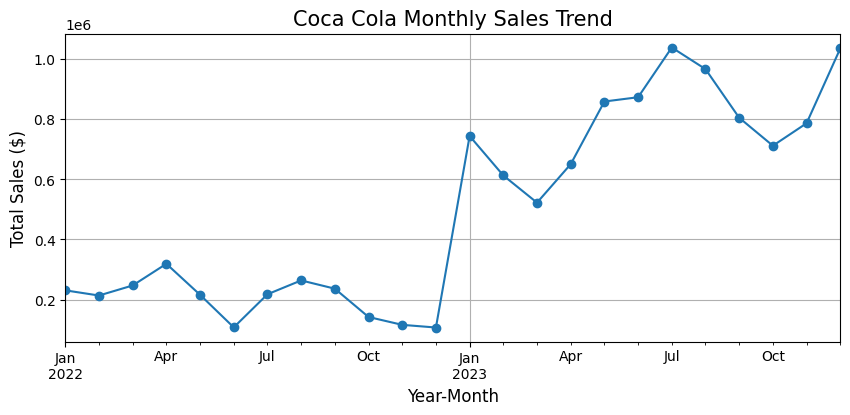

In [ ]:
from numpy._core.fromnumeric import size
from matplotlib.typing import LineStyleType
plt.figure(figsize=(10,4))
monthly_sales.plot(marker = 'o', linestyle = '-')
plt.title('Coca Cola Monthly Sales Trend', fontsize = 15)
plt.xlabel('Year-Month', fontsize = 12)
plt.ylabel('Total Sales ($)', fontsize = 12)
plt.grid(True)
plt.show()
#

Based on the monthly sales trend, here are some key conclusions:



1.   **Significant Growth**: There is a clear and substantial increasein total sales from 2022 to 2023. Sales figures in 2023 are consistently much higher than in the corresponding months of 2022.
2.   **Seasonal Fluctuations**: Both years exhibit seasonal patterns. In 2022, sales saw a peak in April, followed by a noticeable dip in June and then again towards the end of the year. In 2023, sales generally ramped up from January, reaching significant peaks in July and December.

3. **Peak Performance**: July 2023 and December 2023 recorded the highest monthly sales figures in the observed period, indicating strong performance during summer and the holiday season.
4. **Areas for Investigation**: The sharp drop in sales in June 2022 and the overall lower performance in late 2022 compared to 2023 could be areas for further investigation to understand underlying causes or marketing efforts

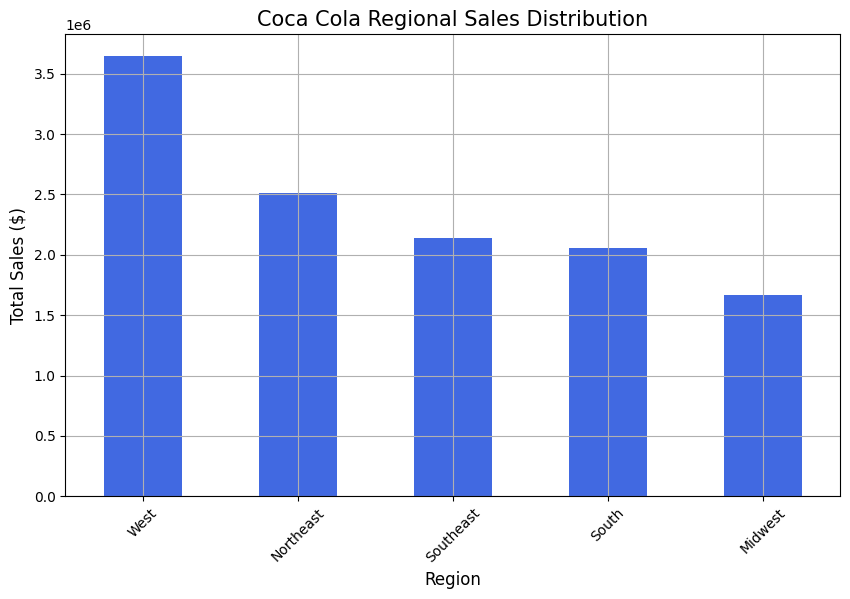

In [ ]:
#Regional Performace
#Aggregate Total sales by Region

regional_sales = df.groupby('Region')['Total Sales'].sum().sort_values(ascending = False)
#plot regional sales distribution
plt.figure(figsize=(10,6))
regional_sales.plot(kind = 'bar', color ='royalblue')
plt.title('Coca Cola Regional Sales Distribution', fontsize = 15)
plt.xlabel('Region', fontsize = 12)
plt.ylabel('Total Sales ($)', fontsize = 12)
plt.xticks(rotation = 45)
plt.grid(True)
plt.show()

**Coca-Cola Regional Sales Distribution**
The bar chart depicting 'Coca Cola Regional Sales Distribution' offers crucial insights into the geographical performance of Coca-Cola sales. The total sales aggregated by region reveal significant disparities, pointing towards distinct market dynamics and potential areas for strategic focus.

**Dominance of the West Region**: The West region stands out as the highest-performing market, with total sales reaching 3,643,785.0 USD. This substantial lead suggests either a higher population density, more effective distribution channels, stronger brand loyalty, or more successful marketing campaigns in this region compared to others. It is a critical revenue driver for Coca-Cola.

**Strong Performance in Northeast and Southeast**: Following the West, the Northeast (2,508,046.0 USD) and Southeast (2,137,538.0 USD) regions demonstrate robust sales. These regions represent significant portions of the total sales and indicate healthy market penetration and consumer demand. Their performance suggests established markets where Coca-Cola has a strong presence.

**Moderate Performance in the South**: The South region, with 2,060,451.0 USD in sales, shows a slightly lower but still considerable contribution. It is closely aligned with the Southeast in terms of sales volume, suggesting similar market conditions or operational strategies.

**Underperformance of the Midwest**: The Midwest region is the lowest-performing market, generating 1,667,581.0 USD in total sales. This noticeable gap compared to the other regions warrants immediate attention. The reasons for this underperformance could be multi-faceted, including higher competition, different consumer preferences, less effective distribution, or lower marketing investment.

**Strategic Implications and Next Steps**:
Leveraging Strengths (West, Northeast, Southeast): For the high-performing regions, Coca-Cola should aim to sustain growth by reinforcing successful strategies, exploring opportunities for market expansion within these regions, and potentially introducing new products or premium offerings. Understanding the drivers of success in the West could provide transferable lessons for other regions.

**Addressing Weaknesses (Midwest):** The Midwest requires a focused investigation. Coca-Cola should conduct a deeper dive into this market to understand the root causes of lower sales. This could involve:

**Market Research**: Analyzing consumer demographics, preferences, and competitor activities.
Distribution Analysis: Evaluating the effectiveness and reach of distribution networks.
Marketing Effectiveness: Assessing current marketing and **promotional efforts**.
Pricing Strategy: Reviewing pricing relative to competitors and local economic conditions.
Operational Efficiency: Identifying any logistical or operational bottlenecks.
Resource Allocation: The sales distribution provides a basis for optimizing resource allocation. More investment (marketing, sales force, new product launches) might be required in underperforming regions like the Midwest to boost sales, while high-performing regions could benefit from investments aimed at maintaining market leadership and exploring incremental growth.

Overall, while Coca-Cola demonstrates strong regional performance in several key markets, the varying sales figures highlight the need for regionally tailored strategies to maximize overall market potential.

In [ ]:
#Aggregare total sales profit by beverage brand

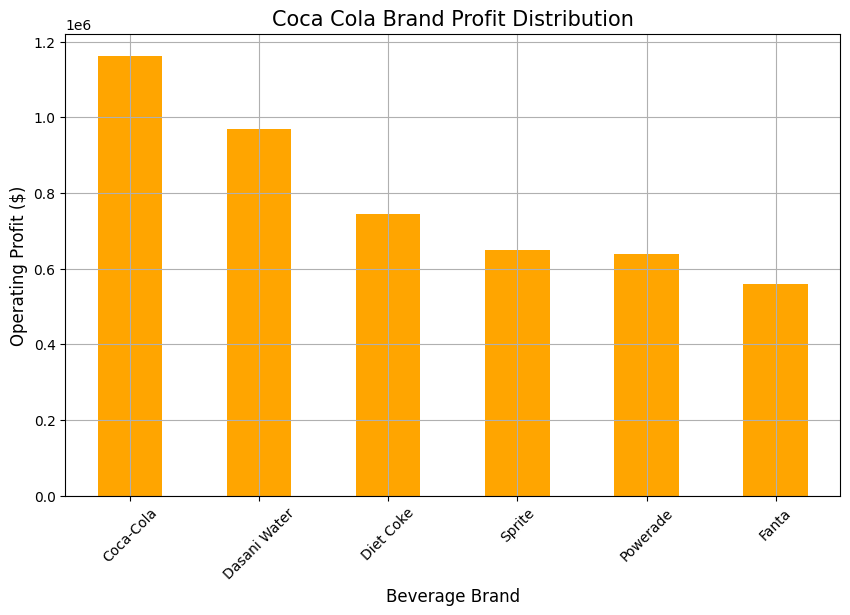

In [ ]:
brand_profit = df.groupby('Beverage Brand')['Operating Profit'].sum().sort_values(ascending = False)
plt.figure(figsize=(10,6))
brand_profit.plot(kind = 'bar', color ='orange')
plt.title('Coca Cola Brand Profit Distribution', fontsize = 15)
plt.xlabel('Beverage Brand', fontsize = 12)
plt.ylabel('Operating Profit ($)', fontsize = 12)
plt.xticks(rotation = 45)
plt.grid(True)
plt.show()

**Coca Cola Brand Profit Distribution' graph, here are the key conclusions:**

**Coca-Cola Leads Significantly**: Coca-Cola is the top-performing brand in terms of operating profit, generating 1,162,968.0 USD. This indicates its strong market presence and high profitability.
**Dasani Water is a Strong Contender**: Dasani Water follows as the second most profitable brand with 968,581.0 USD in operating profit, showcasing its importance to the company's overall profitability.
**Mid-Tier Performers:** Diet Coke (743,814.0 USD), Sprite (649,462.0 USD), and Powerade (638,198.0 USD) form a mid-tier in terms of operating profit. While profitable, they contribute less than **Coca-Cola and Dasani Water.**
Fanta is the Lowest Contributor: Fanta has the lowest operating profit at 559,824.0 USD among the brands listed. This suggests it might have lower sales volume, narrower margins, or face more intense competition.
**Strategic Implications:**

**Focus on Core Brands:** Coca-Cola remains the primary revenue and profit driver. Efforts should continue to maximize its performance.
**Growth Opportunities for Dasani**: Given its strong second position, there might be opportunities to further grow Dasani Water's market share and profitability.
**Evaluate Mid-Tier and Lower Performers:** For brands like Fanta and potentially Powerade, a deeper analysis into their market positioning, marketing strategies, and cost structures could reveal opportunities for improvement or suggest a reallocation of resources.

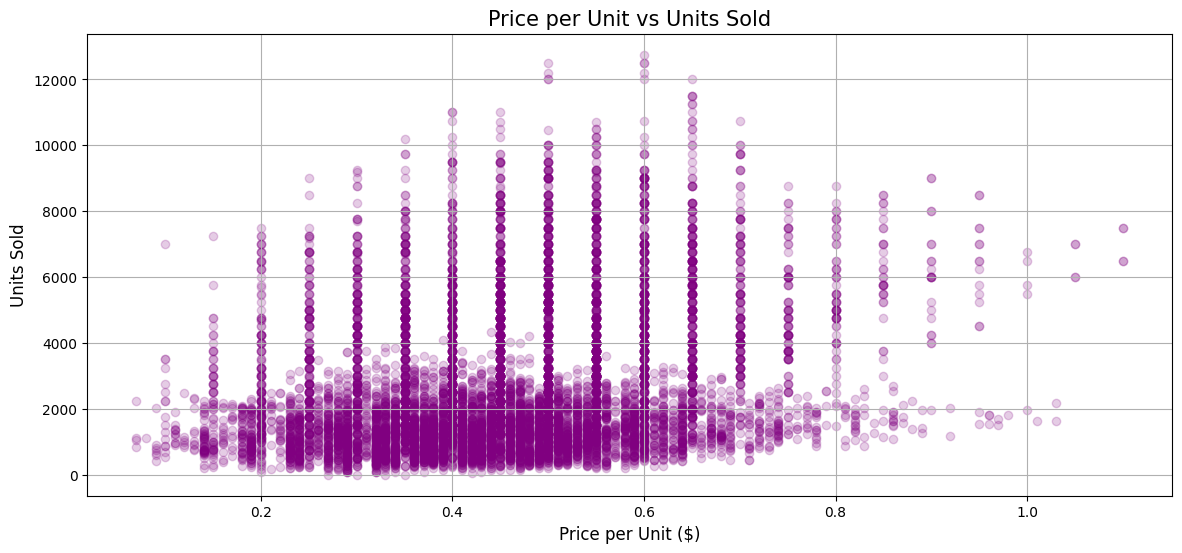

In [ ]:
#price per unit vs Units Sold
plt.figure(figsize=(14,6))
plt.scatter(df['Price per Unit'], df['Units Sold'], alpha = 0.2,color='Purple' )
plt.title('Price per Unit vs Units Sold', fontsize =15)
plt.xlabel('Price per Unit ($)', fontsize = 12)
plt.ylabel('Units Sold', fontsize = 12)
plt.grid(True)


Based on the 'Price per Unit vs Units Sold' scatter plot, here are the key conclusions:

**Inverse Relationship (Demand Curve):** The scatter plot generally shows an inverse relationship between the 'Price per Unit' and 'Units Sold'. As the price per unit increases, the number of units sold tends to decrease. This is consistent with the basic economic principle of the law of demand.
**Concentration at Lower Prices:** A higher density of sales (more data points) appears to be concentrated at lower price points, indicating that a larger volume of units is sold when prices are more affordable.
**Variability at Different Price Points:** While the general trend is clear, there is still some variability in units sold at similar price points, suggesting that factors other than just price (e.g., brand popularity, retailer promotions, seasonality) also influence sales volume.
**Limited High-Price, High-Volume Sales: **There are very few instances of high units sold at high price points, reinforcing the inverse relationship.
In summary, the plot visually confirms that Coca-Cola products generally follow a typical demand curve, where price is a significant factor influencing the quantity of units sold, with lower prices generally leading to higher sales volumes.

In [ ]:
#Create Price Bins
df['Pricel_bin'] = pd.cut(df['Price per Unit'], bins = [0.1, 0.3,0.5,0.7,0.9,1.1],labels=["low","mid-low","mid","mid-high","high"])

/tmp/ipython-input-2875367019.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_profit = df.groupby('Pricel_bin')['Operating Profit'].sum()


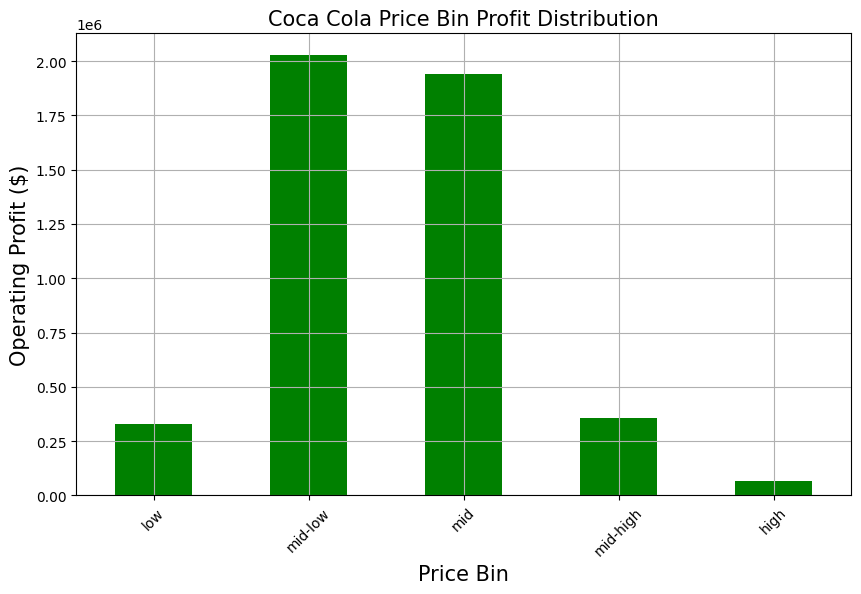

In [ ]:
#Aggregate total profit by price change
price_profit = df.groupby('Pricel_bin')['Operating Profit'].sum()
plt.figure(figsize=(10,6))
price_profit.plot(kind = 'bar', color ='green')
plt.title('Coca Cola Price Bin Profit Distribution', fontsize = 15)
plt.xlabel('Price Bin', fontsize = 15)
plt.ylabel('Operating Profit ($)', fontsize = 15)
plt.xticks(rotation = 45)
plt.grid(True)
plt.show()

Based on the '**Coca Cola Price Bin Profit Distribution' chart, here are the key conclusions regarding profitability across different price bins:**

**Mid-Low and Mid Price Bins Drive Profit: **The 'mid-low' and 'mid' price bins generate the vast majority of the operating profit. The 'mid-low' bin ($0.3 - $0.5) has the highest profit at 2,026,122.0 USD, closely followed by the 'mid' bin ($0.5 - $0.7) at 1,940,349.0 USD.
**Lower and Higher Price Bins Contribute Less:** The 'low' price bin ($0.1 - $0.3) and 'mid-high' price bin ($0.7 - $0.9) contribute significantly less to the overall operating profit, with 330,404.0 USD and 356,621.0 USD respectively.
Highest Price Bin Least Profitable: The 'high' price bin ($0.9 - $1.1) yields the lowest operating profit at 67,478.0 USD.
**Strategic Implications:**

**Optimize Mid-Range Pricing: ** The data strongly suggests that products priced in the 'mid-low' and 'mid' ranges are the most effective in driving profit. Coca-Cola should focus on maintaining strong sales and potentially exploring ways to optimize products within these price points.
**Re-evaluate Low and High Price Strategies:** For products in the 'low' and 'high' price bins, a review might be beneficial. This could involve understanding why higher-priced products generate less profit (e.g., lower sales volume, higher production costs) and whether lower-priced products could be positioned to increase sales volume without significantly eroding margins.

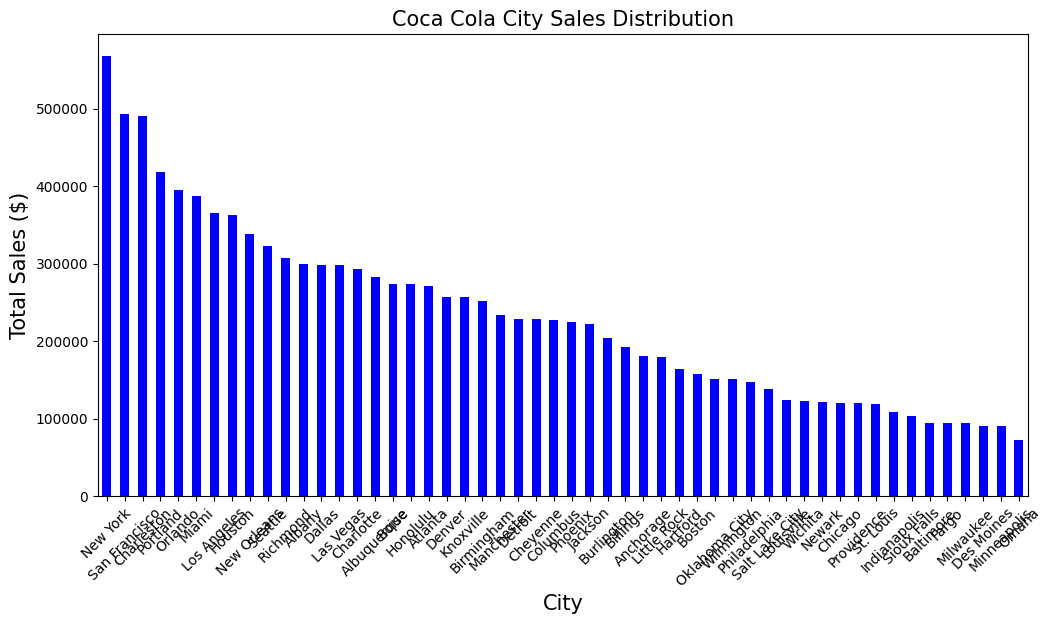

In [ ]:
# Total Profit by City Sales
city_sales = df.groupby('City')['Total Sales'].sum().sort_values(ascending = False)
plt.figure(figsize=(12,6))
city_sales.plot(kind="bar", color="blue")
plt.title('Coca Cola City Sales Distribution', fontsize = 15)
plt.xlabel('City', fontsize = 15)
plt.ylabel('Total Sales ($)', fontsize = 15)
plt.xticks(rotation = 45)
plt.show()

**Based on the 'Coca Cola City Sales Distribution' graph, here are the key conclusions:**

**Leading Cities in Sales:** New York, San Francisco, and Charleston emerge as the top-performing cities in terms of total sales. These cities represent significant revenue generators for Coca-Cola.
**Mid-Range Performers:** Cities like Portland, Orlando, Miami, and Los Angeles show substantial sales, contributing significantly but less than the leading group.
**Lower Sales Cities:** Some cities, such as Boise, Honolulu, and Boston, exhibit comparatively lower total sales. This could be due to various factors like market size, competition, or distribution challenges.
**Strategic Implications:**

**Focus on High-Performing Markets:** Coca-Cola should continue to invest in and optimize strategies for cities with high sales like New York, San Francisco, and Charleston to maintain and grow their market share.
**Investigate Underperforming Cities**: For cities with lower sales, it would be beneficial to conduct a deeper analysis to understand the underlying reasons. This could include market research, competitive analysis, and evaluation of local marketing and distribution efforts.
**Tailored Strategies:** The varying sales across cities highlight the importance of developing tailored sales and marketing strategies for different urban markets to maximize overall sales potential.